# LIBRARY

In [97]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import math
from sklearn.neighbors import LocalOutlierFactor
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import LocalOutlierFactor
from sklearn.model_selection import train_test_split
from pyod.models.lof import LOF
from pyod.models.loda import LODA
from sklearn.ensemble import IsolationForest
from sklearn.decomposition import PCA

In [98]:
import numpy as np
from pyod.models.lof import LOF
from sklearn.model_selection import ParameterSampler
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import LocalOutlierFactor

# READ DATAFRAME

In [99]:
file_path = "../1.DATASET/CMI_FINAL_SCL.csv"
df=pd.read_csv(file_path)

In [100]:
column2drop = ['id']
df.drop(column2drop, axis=1, inplace=True)
attributes = [col for col in df.columns if col != 'sii']
X = df[attributes].values
y = np.array(df['sii'])


## LOF 

In [101]:
param_distributions = {
    'contamination': [0.01],
    'n_neighbors':   [20, 50, 100, 150, 200,256, 300,400, 500],
    'metric':        ['euclidean', 'manhattan']
}

# ── 2. Sampler ───────────────────────────────────────────────────────────────
N_ITER = 20
sampler = ParameterSampler(param_distributions, n_iter=N_ITER, random_state=42)
results = []

# ── 3. Main loop ─────────────────────────────────────────────────────────────
for params in sampler:
    clf = LOF(**params, n_jobs=-1)
    clf.fit(X)

    scores  = clf.decision_scores_   # higher = more anomalous
    labels  = clf.labels_            # 0 = normal, 1 = outlier
    labels_lof=labels

    normal_scores  = scores[labels == 0]
    outlier_scores = scores[labels == 1]

    # ── Quality metrics ──────────────────────────────────────────────────────

    # 1. SEPARATION — how far apart are outlier scores vs normal scores?
    #    Higher = outliers are clearly different from normal points
    separation = np.mean(outlier_scores) - np.mean(normal_scores)

    # 2. CONSISTENCY — how tightly clustered are the normal scores?
    #    Lower std = normals form a clean, stable group
    normal_std = np.std(normal_scores)

    # 3. OUTLIER CONCENTRATION — are outlier scores pushed far out?
    #    Higher = outliers are extreme and unambiguous
    outlier_concentration = np.mean(outlier_scores) / (np.std(outlier_scores) + 1e-9)

    # 4. COMBINED SCORE — single number to rank all runs
    #    We want: high separation, low normal_std, high outlier_concentration
    combined_score = separation / (normal_std + 1e-9) + outlier_concentration

    results.append({
        'params':                params,
        'outlier_fraction':      np.mean(labels),
        'separation':            separation,
        'normal_std':            normal_std,
        'outlier_concentration': outlier_concentration,
        'combined_score':        combined_score,
    })

    print(
        f"neighbors={params['n_neighbors']:<4} "
        f"metric={params['metric']:<10} "
        f"contam={params['contamination']:<6} "
        f"| sep={separation:.3f} "
        f"norm_std={normal_std:.3f} "
        f"conc={outlier_concentration:.3f} "
        f"→ combined={combined_score:.3f}"
    )

# ── 4. Rank results ──────────────────────────────────────────────────────────
results_sorted = sorted(results, key=lambda r: r['combined_score'], reverse=True)
print("\n" + "="*60)
print("TOP 5 CONFIGURATIONS")
print("="*60)
for i, r in enumerate(results_sorted[:5], 1):
    print(f"\n#{i} combined_score = {r['combined_score']:.4f}")
    print(f"   separation          = {r['separation']:.4f}  (want HIGH)")
    print(f"   normal_std          = {r['normal_std']:.4f}  (want LOW) ")
    print(f"   outlier_concentration = {r['outlier_concentration']:.4f}  (want HIGH)")
    print(f"   outlier_fraction    = {r['outlier_fraction']:.4f}")
    print(f"   params              = {r['params']}")

# ── 5. Best config ───────────────────────────────────────────────────────────
best = results_sorted[0]
print("\n" + "="*60)
print("BEST PARAMS →", best['params'])
print("="*60)

c:\Users\paula\anaconda3\Lib\site-packages\sklearn\model_selection\_search.py:317: UserWarning: The total space of parameters 18 is smaller than n_iter=20. Running 18 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


neighbors=20   metric=euclidean  contam=0.01   | sep=1.228 norm_std=0.163 conc=1.904 → combined=9.427
neighbors=50   metric=euclidean  contam=0.01   | sep=1.508 norm_std=0.151 conc=1.411 → combined=11.394
neighbors=100  metric=euclidean  contam=0.01   | sep=1.562 norm_std=0.151 conc=1.311 → combined=11.665
neighbors=150  metric=euclidean  contam=0.01   | sep=1.584 norm_std=0.154 conc=1.315 → combined=11.614
neighbors=200  metric=euclidean  contam=0.01   | sep=1.618 norm_std=0.156 conc=1.331 → combined=11.684
neighbors=256  metric=euclidean  contam=0.01   | sep=1.648 norm_std=0.158 conc=1.340 → combined=11.767
neighbors=300  metric=euclidean  contam=0.01   | sep=1.665 norm_std=0.159 conc=1.338 → combined=11.844
neighbors=400  metric=euclidean  contam=0.01   | sep=1.691 norm_std=0.158 conc=1.353 → combined=12.064
neighbors=500  metric=euclidean  contam=0.01   | sep=1.704 norm_std=0.156 conc=1.380 → combined=12.307
neighbors=20   metric=manhattan  contam=0.01   | sep=1.692 norm_std=0.246 

In [102]:
clf = LOF(n_neighbors=200, metric= 'euclidean', contamination= 0.01)
clf.fit(X)
outliers = clf.predict(X)
np.unique(outliers, return_counts=True)

(array([0, 1]), array([8382,   78], dtype=int64))

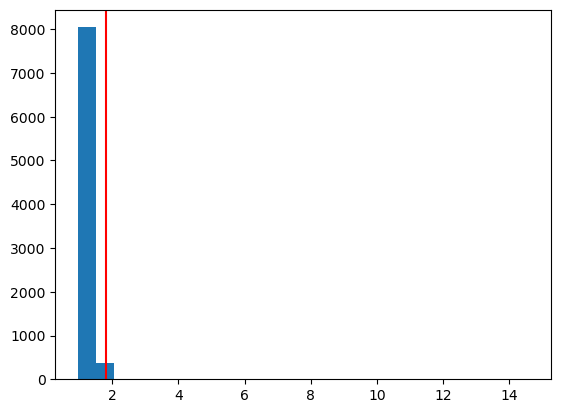

In [103]:
df['lof'] = outliers
df['lof_score']=clf.decision_scores_
plt.hist(clf.decision_function(X), bins=25)
plt.axvline(np.min(clf.decision_function(X)[np.where(outliers==1)]), c='r')
plt.show()

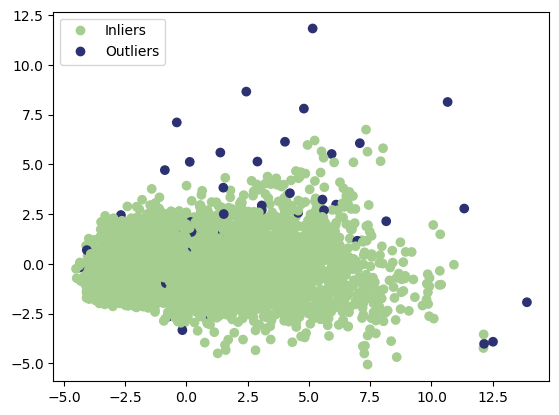

In [104]:
pca = PCA(n_components=2)
pca_data = pd.DataFrame(pca.fit_transform(X), columns=['PC1', 'PC2'])
pca_data['outlier score'] = pd.Categorical(outliers)

fig = plt.figure()
ax = fig.add_subplot()

scatter = ax.scatter(pca_data['PC1'],
                     pca_data['PC2'],
                     c=pca_data['outlier score'],
                     cmap='crest')

handles, labels = scatter.legend_elements()
plt.legend(handles, ['Inliers', 'Outliers'], loc='upper left')

plt.show()

In [105]:
df[df['lof']==1]

,Basic_Demos-Age,Basic_Demos-Sex,Physical-BMI,Physical-Height,Physical-Weight,Physical-MAP_CAL,FGC-FGC_CORE_CAL,FGC-FGC_GS_CAL,FGC-FGC_SR_CAL,BIA-BIA_Activity_Level_num,BIA-BIA_BMC,BIA-BIA_DEE,BIA-BIA_FFM,BIA-BIA_Fat,BIA-BIA_Frame_num,BIA-BIA_SMM,BIA-BIA_TBW,sii,lof,lof_score
18,-1.186243,-0.820524,2.372831,-2.439051,-0.765276,-1.266210,-0.826682,-0.289581,-2.168466,-0.933083,-0.854355,-0.174550,-0.698228,-0.600141,-1.264876,-0.829773,-0.416645,0.0,1,1.831337
59,1.891137,-0.820524,1.119982,1.485392,1.642694,1.066269,2.717543,16.823357,1.032039,1.493563,-0.556933,0.118269,2.182005,0.020963,0.498323,-0.352442,-0.153513,2.0,1,3.196922
180,-1.186243,1.218734,-1.021966,-0.830673,-0.947190,-2.295245,-0.999571,-0.289581,1.770617,-0.933083,6.931916,-0.164988,-0.639429,-1.159717,-1.264876,0.209956,-1.205336,0.0,1,2.261852
319,-1.186243,-0.820524,-1.072481,-1.667029,-1.267934,6.074239,-0.802428,-0.289581,-1.060599,-0.933083,-1.067328,-0.213255,-1.134802,-1.035222,-1.264876,-1.397926,-1.455736,0.0,1,1.891720
431,-0.906481,-0.820524,-0.789637,-0.702002,-0.803574,3.192942,2.112432,-0.236957,4.724929,0.280240,0.783306,-0.102769,-0.710429,-0.672357,0.498323,-0.636205,-0.682354,0.0,1,1.894820
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7655,-1.186243,1.218734,-0.351580,-0.725163,-0.639807,-0.477283,-0.802428,1.982753,-2.168466,-0.933083,0.156701,-0.033020,-2.093603,2.298735,0.498323,-2.227138,-0.156411,0.0,1,1.907092
7704,-0.067196,1.218734,-0.197857,-0.287684,-0.353836,-0.000778,0.080986,8.044034,0.293461,0.280240,0.569303,-0.078341,-0.342349,-0.241290,-1.264876,1.238087,0.093292,0.0,1,2.095720
7764,-0.346958,-0.820524,-0.405399,-0.811372,-0.701613,-0.048543,-0.437681,-0.358400,1.278231,0.280240,0.612389,-0.191764,-2.176126,2.298735,-1.264876,-2.332225,-0.759709,2.0,1,1.896550
7968,0.772090,-0.820524,-0.366238,0.359527,-0.084930,-0.631638,-0.091903,-0.637742,-0.198925,1.493563,-0.360841,0.271612,-1.780139,3.091484,0.498323,-1.827961,0.483991,0.0,1,1.929740


In [106]:
df_out=df[df['lof']==1].copy()
list_out_lof=df_out.index.values.tolist()
total_list=df_out.index.values.tolist()
file_path = "../1.DATASET/CMI_FINAL.csv"
df_original=pd.read_csv(file_path)
df_original[df_original['id'].isin(list_out_lof)]

,id,Basic_Demos-Age,Basic_Demos-Sex,Physical-BMI,Physical-Height,Physical-Weight,Physical-MAP_CAL,FGC-FGC_CORE_CAL,FGC-FGC_GS_CAL,FGC-FGC_SR_CAL,BIA-BIA_Activity_Level_num,BIA-BIA_BMC,BIA-BIA_DEE,BIA-BIA_FFM,BIA-BIA_Fat,BIA-BIA_Frame_num,BIA-BIA_SMM,BIA-BIA_TBW,sii
18,18,6,0,30.094649,37.50,60.200000,72.333333,6.00000,18.613018,4.00,2.0,2.750350,1504.610000,49.103400,11.096600,1.0,19.888600,38.763800,0.0
59,59,17,0,24.446886,68.00,160.800000,95.000000,47.00000,115.100000,10.50,4.0,3.502280,2298.130000,139.225600,21.574400,2.0,25.752900,42.541600,2.0
180,180,6,1,14.791120,50.00,52.600000,62.333333,4.00000,18.613018,12.00,2.0,22.435300,1530.520000,50.943230,1.656770,1.0,32.662300,27.440500,0.0
319,319,6,0,14.563403,43.50,39.200000,143.666667,6.28057,18.613018,6.25,2.0,2.211920,1399.720000,35.443050,3.756950,1.0,12.908500,23.845500,0.0
431,431,7,0,15.838447,51.00,58.600000,115.666667,40.00000,18.909726,18.00,3.0,6.890620,1699.130000,48.721650,9.878350,2.0,22.266700,34.949000,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7655,7655,6,1,17.813178,50.82,65.441825,80.000000,6.28057,31.425000,4.00,2.0,5.306462,1888.146627,5.442259,59.999567,2.0,2.721129,42.500000,0.0
7704,7704,10,1,18.506154,54.22,77.389115,84.630603,16.50000,65.600000,9.00,3.0,6.349588,1765.330589,60.238836,17.150279,1.0,45.293513,46.084999,0.0
7764,7764,9,0,17.570567,50.15,62.859703,84.166427,10.50000,18.225000,11.00,3.0,6.458514,1457.960761,2.860137,59.999567,1.0,1.430068,33.838410,2.0
7968,7968,13,0,17.747100,59.25,88.623475,78.500000,14.50000,16.650000,8.00,4.0,3.998032,2713.680000,15.250529,73.372946,2.0,7.625265,51.694288,0.0


In [107]:
df.sort_values(by='lof_score', ascending=False)

,Basic_Demos-Age,Basic_Demos-Sex,Physical-BMI,Physical-Height,Physical-Weight,Physical-MAP_CAL,FGC-FGC_CORE_CAL,FGC-FGC_GS_CAL,FGC-FGC_SR_CAL,BIA-BIA_Activity_Level_num,BIA-BIA_BMC,BIA-BIA_DEE,BIA-BIA_FFM,BIA-BIA_Fat,BIA-BIA_Frame_num,BIA-BIA_SMM,BIA-BIA_TBW,sii,lof,lof_score
3205,-0.346958,1.218734,-0.538115,-0.315992,-0.521128,1.615088,-0.913126,-0.362028,-0.322021,-0.933083,-0.815152,45.296331,-0.498768,-0.365465,0.498323,-0.196215,1.529170,0.0,1,14.670397
5448,-0.067196,-0.820524,-0.461258,0.452170,-0.085512,-0.871746,0.599653,6.332509,-2.168466,-0.933083,0.693365,45.296331,-0.038054,-0.141189,0.498323,0.777032,0.983779,0.0,1,11.361473
6273,1.611376,-0.820524,2.702671,1.719571,3.035697,3.604556,-0.091903,1.147225,0.293461,0.280240,0.719826,45.296331,1.279724,5.144318,2.261521,2.321604,2.457557,0.0,1,9.746571
5615,0.772090,1.218734,0.111018,1.193310,0.720930,-0.408681,0.340319,1.933979,1.770617,1.493563,0.462944,29.146070,0.702161,0.483023,0.498323,1.369306,1.995972,0.0,1,7.587015
6763,0.492328,1.218734,-0.194977,1.539433,0.745555,-1.077553,-0.005459,0.612647,-1.429888,-2.146406,0.279029,21.240536,0.245653,1.390742,0.498323,0.728534,-0.217937,2.0,1,7.035889
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7886,-0.626720,-0.820524,-0.243508,-0.852547,-0.659054,-0.176169,-0.431777,-0.398306,0.047268,0.280240,-0.238514,-0.097927,-0.575317,-0.565058,-1.264876,-0.614083,-0.662749,0.0,0,0.959790
1849,-0.346958,-0.820524,-0.323961,-0.235444,-0.383748,-0.048543,-0.308015,-0.362028,0.043536,0.280240,-0.589611,-0.029414,-0.339509,-0.320636,0.498323,-0.489749,-0.156411,0.0,0,0.959650
3089,-0.346958,-0.820524,-0.487602,-0.187322,-0.434686,-0.048543,-0.308015,-0.362028,0.043536,0.280240,-0.589611,-0.029414,-0.379665,-0.372302,0.498323,-0.489749,-0.164769,0.0,0,0.959385
3562,-0.346958,-0.820524,-0.487602,-0.092106,-0.386695,-0.048543,-0.239970,-0.362028,0.043536,0.280240,-0.589611,-0.029414,-0.315588,-0.372302,0.498323,-0.362063,-0.164769,0.0,0,0.959363


In [108]:
df_original[df_original['id']==3205]

,id,Basic_Demos-Age,Basic_Demos-Sex,Physical-BMI,Physical-Height,Physical-Weight,Physical-MAP_CAL,FGC-FGC_CORE_CAL,FGC-FGC_GS_CAL,FGC-FGC_SR_CAL,BIA-BIA_Activity_Level_num,BIA-BIA_BMC,BIA-BIA_DEE,BIA-BIA_FFM,BIA-BIA_Fat,BIA-BIA_Frame_num,BIA-BIA_SMM,BIA-BIA_TBW,sii
3205,3205,9,1,16.972291,54.0,70.4,100.333333,5.0,18.204545,7.75,2.0,2.84946,124728.0,55.3445,15.0555,2.0,27.67225,66.7,0.0


## LODA

In [109]:
import numpy as np
from pyod.models.loda import LODA
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import ParameterSampler

# ── 1. Search space ───────────────────────────────────────────────────────────
param_distributions = {
    'contamination':  [0.01],
    'n_bins':         ['auto'],   # histogram granularity
    'n_random_cuts':  [50, 100, 150, 200, 256, 500], # number of 1D projections
}

# ── 2. Sampler ────────────────────────────────────────────────────────────────
N_ITER = 20
sampler = ParameterSampler(param_distributions, n_iter=N_ITER, random_state=42)
results = []

# ── 3. Main loop ──────────────────────────────────────────────────────────────
print("="*80)
print(f"{'n_bins':<10}{'n_cuts':<10}{'contam':<10}{'sep':<10}{'norm_std':<12}{'conc':<10}{'combined'}")
print("="*80)

for params in sampler:
    contamination = params['contamination']

    clf = LODA(
        contamination=contamination,
        n_bins=params['n_bins'],
        n_random_cuts=params['n_random_cuts'],
    )
    clf.fit(X)

    # PyOD gives these directly — no flipping needed like sklearn
    scores = clf.decision_scores_   # higher = more anomalous
    labels = clf.labels_            # 0 = normal, 1 = outlier
    labels_loda=labels
    
    normal_scores  = scores[labels == 0]
    outlier_scores = scores[labels == 1]

    # ── Quality metrics ───────────────────────────────────────────────────────
    separation            = np.mean(outlier_scores) - np.mean(normal_scores)
    normal_std            = np.std(normal_scores)
    outlier_concentration = np.mean(outlier_scores) / (np.std(outlier_scores) + 1e-9)
    combined_score        = separation / (normal_std + 1e-9) + outlier_concentration

    results.append({
        'params':                params,
        'scores':                scores,
        'labels':                labels,
        'outlier_fraction':      np.mean(labels),
        'separation':            separation,
        'normal_std':            normal_std,
        'outlier_concentration': outlier_concentration,
        'combined_score':        combined_score,
    })

    print(
        f"{params['n_bins']:<10}"
        f"{params['n_random_cuts']:<10}"
        f"{contamination:<10}"
        f"{separation:<10.3f}"
        f"{normal_std:<12.3f}"
        f"{outlier_concentration:<10.3f}"
        f"{combined_score:.3f}"
    )

# ── 4. Rank results ───────────────────────────────────────────────────────────
results_sorted = sorted(results, key=lambda r: r['combined_score'], reverse=True)

print("\n" + "="*60)
print("TOP 5 CONFIGURATIONS")
print("="*60)
for i, r in enumerate(results_sorted[:5], 1):
    print(f"\n#{i} combined_score        = {r['combined_score']:.4f}")
    print(f"   separation            = {r['separation']:.4f}  (want HIGH)")
    print(f"   normal_std            = {r['normal_std']:.4f}  (want LOW) ")
    print(f"   outlier_concentration = {r['outlier_concentration']:.4f}  (want HIGH)")
    print(f"   outlier_fraction      = {r['outlier_fraction']:.4f}")
    print(f"   params                = {r['params']}")

# ── 5. Best config ────────────────────────────────────────────────────────────
best = results_sorted[0]
print("\n" + "="*60)
print("BEST PARAMS →", best['params'])
print("="*60)


n_bins    n_cuts    contam    sep       norm_std    conc      combined


c:\Users\paula\anaconda3\Lib\site-packages\sklearn\model_selection\_search.py:317: UserWarning: The total space of parameters 6 is smaller than n_iter=20. Running 6 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


auto      50        0.01      0.038     0.007       6.172     12.070
auto      100       0.01      0.016     0.002       4.754     12.130
auto      150       0.01      0.013     0.002       4.910     11.905
auto      200       0.01      0.008     0.001       5.326     12.467
auto      256       0.01      0.006     0.001       5.229     12.363
auto      500       0.01      0.003     0.000       4.637     12.578

TOP 5 CONFIGURATIONS

#1 combined_score        = 12.5780
   separation            = 0.0032  (want HIGH)
   normal_std            = 0.0004  (want LOW) 
   outlier_concentration = 4.6369  (want HIGH)
   outlier_fraction      = 0.0100
   params                = {'n_random_cuts': 500, 'n_bins': 'auto', 'contamination': 0.01}

#2 combined_score        = 12.4669
   separation            = 0.0083  (want HIGH)
   normal_std            = 0.0012  (want LOW) 
   outlier_concentration = 5.3263  (want HIGH)
   outlier_fraction      = 0.0100
   params                = {'n_random_cuts': 200, '

In [110]:
clf = LODA(contamination=0.01, n_bins='auto', n_random_cuts=150)

In [111]:
clf.fit(X)
outliers = clf.predict(X)
np.unique(outliers, return_counts=True)

(array([0, 1]), array([8375,   85], dtype=int64))

In [112]:
df['loda'] = outliers

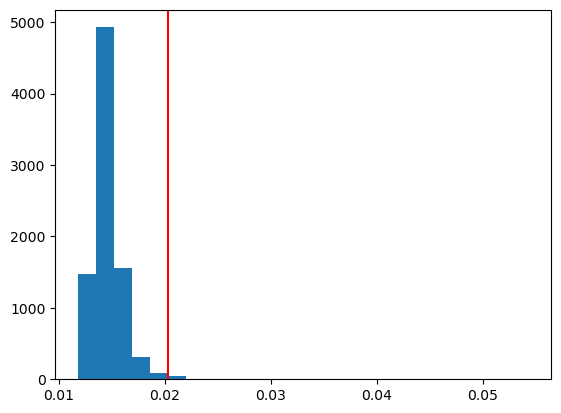

In [113]:
plt.hist(clf.decision_function(X), bins=25)
plt.axvline(np.min(clf.decision_function(X)[np.where(outliers==1)]), c='r')

plt.show()

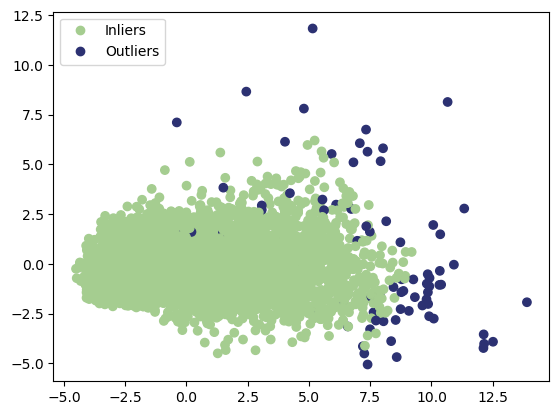

In [114]:
pca = PCA(n_components=2)
pca_data = pd.DataFrame(pca.fit_transform(X), columns=['PC1', 'PC2'])
pca_data['outlier score'] = pd.Categorical(outliers)

fig = plt.figure()
ax = fig.add_subplot()

scatter = ax.scatter(pca_data['PC1'],
                     pca_data['PC2'],
                     c=pca_data['outlier score'],
                     cmap='crest')

handles, labels = scatter.legend_elements()
plt.legend(handles, ['Inliers', 'Outliers'], loc='upper left')

plt.show()

In [115]:
df[df['loda']==1]

,Basic_Demos-Age,Basic_Demos-Sex,Physical-BMI,Physical-Height,Physical-Weight,Physical-MAP_CAL,FGC-FGC_CORE_CAL,FGC-FGC_GS_CAL,FGC-FGC_SR_CAL,BIA-BIA_Activity_Level_num,...,BIA-BIA_DEE,BIA-BIA_FFM,BIA-BIA_Fat,BIA-BIA_Frame_num,BIA-BIA_SMM,BIA-BIA_TBW,sii,lof,lof_score,loda
59,1.891137,-0.820524,1.119982,1.485392,1.642694,1.066269,2.717543,16.823357,1.032039,1.493563,...,0.118269,2.182005,0.020963,0.498323,-0.352442,-0.153513,2.0,1,3.196922,1
180,-1.186243,1.218734,-1.021966,-0.830673,-0.947190,-2.295245,-0.999571,-0.289581,1.770617,-0.933083,...,-0.164988,-0.639429,-1.159717,-1.264876,0.209956,-1.205336,0.0,1,2.261852,1
306,1.611376,-0.820524,5.923960,1.421056,4.945873,1.615088,-0.394459,2.545871,-2.783948,-2.146406,...,0.335613,3.447218,5.854619,2.261521,4.250539,6.081284,3.0,0,1.703390,1
489,1.891137,-0.820524,3.464803,1.678397,3.552793,3.844664,1.247987,5.827033,3.321630,2.706886,...,1.138110,3.066769,3.110291,0.498323,5.521929,5.508395,0.0,1,1.904966,1
570,1.331614,-0.820524,3.040605,1.614062,3.160241,3.535953,0.556430,3.033612,1.032039,-0.933083,...,0.509425,3.031851,2.202897,2.261521,5.279646,5.489589,1.0,0,1.442806,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7207,2.730423,-0.820524,4.018201,2.073415,4.520142,0.386483,-0.264792,0.946675,-0.112757,0.280240,...,0.280623,3.484901,4.730393,2.261521,3.050793,2.471919,2.0,0,1.248432,1
7224,-0.346958,1.218734,-0.310137,1.367750,0.552001,-0.048543,-0.239970,-0.362028,0.043536,0.280240,...,-0.098213,0.917796,-0.335295,-1.264876,-0.012932,-1.035470,0.0,1,3.851535,1
7304,-0.346958,-0.820524,-0.731173,0.044285,-0.437447,-0.391530,-0.239970,-0.970292,-2.660851,-2.146406,...,-0.077467,-0.199839,-0.712682,0.498323,-0.346137,-0.589404,0.0,1,3.171479,1
7475,1.891137,-0.820524,3.795740,2.155763,4.456298,1.289227,0.945431,3.242010,-0.198925,-0.933083,...,0.390591,5.614364,0.622540,2.261521,2.867501,3.821094,1.0,0,1.324728,1


In [116]:
df_out=df[df['loda']==1].copy()
list_out_loda=df_out.index.values.tolist()
total_list= total_list+list_out_loda
file_path = "../1.DATASET/CMI_FINAL.csv"
df_original=pd.read_csv(file_path)
df_original[df_original['id'].isin(list_out_loda)]

,id,Basic_Demos-Age,Basic_Demos-Sex,Physical-BMI,Physical-Height,Physical-Weight,Physical-MAP_CAL,FGC-FGC_CORE_CAL,FGC-FGC_GS_CAL,FGC-FGC_SR_CAL,BIA-BIA_Activity_Level_num,BIA-BIA_BMC,BIA-BIA_DEE,BIA-BIA_FFM,BIA-BIA_Fat,BIA-BIA_Frame_num,BIA-BIA_SMM,BIA-BIA_TBW,sii
59,59,17,0,24.446886,68.000000,160.800000,95.000000,47.000000,115.100000,10.50000,4.0,3.502280,2298.130000,139.225600,21.574400,2.0,25.752900,42.541600,2.0
180,180,6,1,14.791120,50.000000,52.600000,62.333333,4.000000,18.613018,12.00000,2.0,22.435300,1530.520000,50.943230,1.656770,1.0,32.662300,27.440500,0.0
306,306,16,0,46.102914,67.500000,298.800000,100.333333,11.000000,34.600000,2.75000,1.0,7.434780,2887.120000,178.814000,119.986000,3.0,82.303300,132.055000,3.0
489,489,17,0,35.017194,69.500000,240.600000,122.000000,30.000000,53.100000,15.15000,5.0,11.632400,5061.840000,166.909800,73.690200,2.0,97.923100,123.830000,0.0
570,570,15,0,33.104936,69.000000,224.200000,119.000000,22.000000,37.350000,10.50000,2.0,7.882090,3358.140000,165.817200,58.382800,3.0,94.946500,123.560000,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7207,7207,20,0,37.511877,72.570000,281.013843,88.393939,12.500000,25.583333,8.17500,3.0,9.286550,2738.100000,179.993113,101.020730,3.0,67.563704,80.235114,2.0
7224,7224,9,1,18.000000,67.085714,115.233108,84.166427,12.787145,18.204545,8.49242,3.0,41.515953,1711.477348,99.668648,15.564460,1.0,29.923986,29.879288,0.0
7304,7304,9,0,16.101998,56.800000,73.896033,80.833333,12.787145,14.775000,3.00000,1.0,33.027024,1767.697081,64.697952,9.198081,2.0,25.830364,36.283486,0.0
7475,7475,17,0,36.509036,73.210000,278.346559,97.166667,26.500000,38.525000,8.00000,2.0,7.069773,3036.108086,246.623780,31.722779,3.0,65.311851,99.605311,1.0


## Isolation Forest

In [117]:
import numpy as np
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import ParameterSampler

# ── 1. Search space ───────────────────────────────────────────────────────────
param_distributions = {
    'contamination':  [0.01],
    'n_estimators':   [50, 100, 150, 200, 256, 500],   # number of trees
    'max_samples':    ['auto'],  # rows per tree
    'max_features':   [1.0]                # features per tree
}

# ── 2. Sampler ────────────────────────────────────────────────────────────────
N_ITER = 20
sampler = ParameterSampler(param_distributions, n_iter=N_ITER, random_state=42)
results = []

# ── 3. Main loop ──────────────────────────────────────────────────────────────
print("="*90)
print(f"{'n_est':<8}{'max_samp':<12}{'max_feat':<12}{'bootstrap':<12}{'sep':<10}{'norm_std':<12}{'conc':<10}{'combined'}")
print("="*90)

for params in sampler:
    contamination = params['contamination']
    if_params     = {k: v for k, v in params.items() if k != 'contamination'}

    clf = IsolationForest(
        **if_params,
        contamination=contamination,
        random_state=42,
        n_jobs=-1
    )
    clf.fit(X)

    # sklearn IsolationForest — same flipping trick as LOF
    # score_samples() → more negative = more anomalous → flip it
    scores    = -clf.score_samples(X)        # higher = more anomalous
    threshold = np.percentile(scores, 100 * (1 - contamination))
    labels    = (scores > threshold).astype(int)    # 1 = outlier, 0 = normal

    normal_scores  = scores[labels == 0]
    outlier_scores = scores[labels == 1]

    # ── Quality metrics ───────────────────────────────────────────────────────
    separation            = np.mean(outlier_scores) - np.mean(normal_scores)
    normal_std            = np.std(normal_scores)
    outlier_concentration = np.mean(outlier_scores) / (np.std(outlier_scores) + 1e-9)
    combined_score        = separation / (normal_std + 1e-9) + outlier_concentration

    results.append({
        'params':                params,
        'scores':                scores,
        'labels':                labels,
        'outlier_fraction':      np.mean(labels),
        'separation':            separation,
        'normal_std':            normal_std,
        'outlier_concentration': outlier_concentration,
        'combined_score':        combined_score,
    })

    print(
        f"{params['n_estimators']:<8}"
        f"{str(params['max_samples']):<12}"
        f"{str(params['max_features']):<12}"
        f"{separation:<10.3f}"
        f"{normal_std:<12.3f}"
        f"{outlier_concentration:<10.3f}"
        f"{combined_score:.3f}"
    )

# ── 4. Rank results ───────────────────────────────────────────────────────────
results_sorted = sorted(results, key=lambda r: r['combined_score'], reverse=True)

print("\n" + "="*60)
print("TOP 5 CONFIGURATIONS")
print("="*60)
for i, r in enumerate(results_sorted[:5], 1):
    print(f"\n#{i} combined_score        = {r['combined_score']:.4f}")
    print(f"   separation            = {r['separation']:.4f}  (want HIGH)")
    print(f"   normal_std            = {r['normal_std']:.4f}  (want LOW) ")
    print(f"   outlier_concentration = {r['outlier_concentration']:.4f}  (want HIGH)")
    print(f"   outlier_fraction      = {r['outlier_fraction']:.4f}")
    print(f"   params                = {r['params']}")

# ── 5. Best config ────────────────────────────────────────────────────────────
best = results_sorted[0]
print("\n" + "="*60)
print("BEST PARAMS →", best['params'])
print("="*60)



n_est   max_samp    max_feat    bootstrap   sep       norm_std    conc      combined
50      auto        1.0         0.213     0.049       24.757    29.068


c:\Users\paula\anaconda3\Lib\site-packages\sklearn\model_selection\_search.py:317: UserWarning: The total space of parameters 6 is smaller than n_iter=20. Running 6 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


100     auto        1.0         0.208     0.048       25.129    29.509
150     auto        1.0         0.208     0.048       25.552    29.892
200     auto        1.0         0.205     0.048       26.359    30.651
256     auto        1.0         0.202     0.047       25.709    30.006
500     auto        1.0         0.200     0.046       25.688    29.999

TOP 5 CONFIGURATIONS

#1 combined_score        = 30.6508
   separation            = 0.2055  (want HIGH)
   normal_std            = 0.0479  (want LOW) 
   outlier_concentration = 26.3588  (want HIGH)
   outlier_fraction      = 0.0100
   params                = {'n_estimators': 200, 'max_samples': 'auto', 'max_features': 1.0, 'contamination': 0.01}

#2 combined_score        = 30.0057
   separation            = 0.2022  (want HIGH)
   normal_std            = 0.0471  (want LOW) 
   outlier_concentration = 25.7095  (want HIGH)
   outlier_fraction      = 0.0100
   params                = {'n_estimators': 256, 'max_samples': 'auto', 'max_featur

In [118]:
clf = IsolationForest(random_state=42, n_estimators=150, contamination=0.01, n_jobs=-1)

In [119]:
clf.fit(X)
outliers = clf.predict(X)

In [120]:
df['iforest'] = outliers
# Mapping all outliers to 1 and all inliers to 0
df['iforest'] = df['iforest'].map({-1: 1, 1: 0})
np.unique(outliers, return_counts=True)

(array([-1,  1]), array([  85, 8375], dtype=int64))

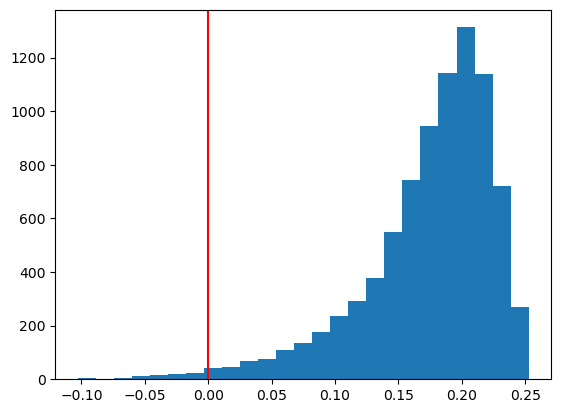

In [121]:
plt.hist(clf.decision_function(X), bins=25)
plt.axvline(np.min(clf.decision_function(X)[np.where(outliers==1)]), c='r')

plt.show()

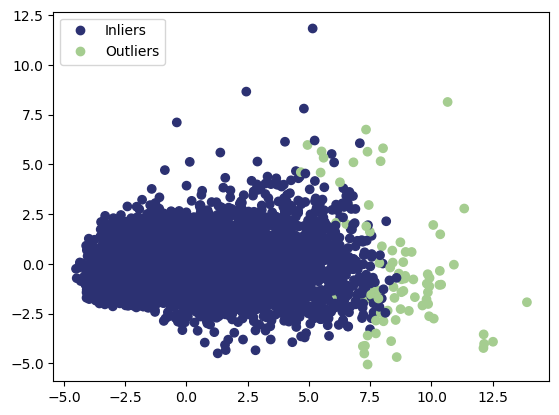

In [122]:
pca = PCA(n_components=2)
pca_data = pd.DataFrame(pca.fit_transform(X), columns=['PC1', 'PC2'])
pca_data['outlier score'] = pd.Categorical(outliers)

fig = plt.figure()
ax = fig.add_subplot()

scatter = ax.scatter(pca_data['PC1'],
                     pca_data['PC2'],
                     c=pca_data['outlier score'],
                     cmap='crest')

handles, labels = scatter.legend_elements()
plt.legend(reversed(handles), ['Inliers', 'Outliers'], loc='upper left')

plt.show()

In [123]:
df[df['iforest']==1]

,Basic_Demos-Age,Basic_Demos-Sex,Physical-BMI,Physical-Height,Physical-Weight,Physical-MAP_CAL,FGC-FGC_CORE_CAL,FGC-FGC_GS_CAL,FGC-FGC_SR_CAL,BIA-BIA_Activity_Level_num,...,BIA-BIA_FFM,BIA-BIA_Fat,BIA-BIA_Frame_num,BIA-BIA_SMM,BIA-BIA_TBW,sii,lof,lof_score,loda,iforest
87,1.891137,-0.820524,1.604434,2.643424,3.169816,1.169173,3.668433,4.576644,4.109447,0.280240,...,4.079742,0.282971,0.498323,-0.362063,-0.217937,0.0,0,1.709852,0,1
306,1.611376,-0.820524,5.923960,1.421056,4.945873,1.615088,-0.394459,2.545871,-2.783948,-2.146406,...,3.447218,5.854619,2.261521,4.250539,6.081284,3.0,0,1.703390,1,1
459,1.331614,-0.820524,1.877108,2.482586,3.236837,0.386664,1.075098,3.015876,0.293461,0.280240,...,2.798459,2.825483,2.261521,3.906176,4.933069,2.0,0,1.214293,0,1
489,1.891137,-0.820524,3.464803,1.678397,3.552793,3.844664,1.247987,5.827033,3.321630,2.706886,...,3.066769,3.110291,0.498323,5.521929,5.508395,0.0,1,1.904966,1,1
570,1.331614,-0.820524,3.040605,1.614062,3.160241,3.535953,0.556430,3.033612,1.032039,-0.933083,...,3.031851,2.202897,2.261521,5.279646,5.489589,1.0,0,1.442806,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7734,1.891137,-0.820524,3.819542,1.753026,3.916722,0.435384,0.945431,1.424069,0.047268,2.706886,...,4.234252,1.846113,0.498323,3.345438,2.242476,0.0,0,1.250413,0,1
7897,2.450661,-0.820524,3.858357,1.791627,3.998767,-0.871746,2.328543,1.561523,-0.198925,0.280240,...,4.733316,1.123631,0.498323,2.595145,2.368906,0.0,0,1.234503,0,1
8155,1.331614,-0.820524,4.398420,1.583181,4.108318,-0.563036,-0.351237,1.094617,0.293461,-2.146406,...,3.145329,4.340344,2.261521,1.112424,1.256820,0.0,0,1.264705,0,1
8193,0.492328,-0.820524,3.271192,1.707991,3.446481,0.980517,2.328543,0.067458,-2.660851,-2.146406,...,4.194492,0.755298,0.498323,3.544814,3.778003,0.0,0,1.355891,0,1


In [124]:
df_out=df[df['iforest']==1].copy()
list_out_iforest=df_out.index.values.tolist()
total_list= total_list+list_out_iforest
file_path = "../1.DATASET/CMI_FINAL.csv"
df_original=pd.read_csv(file_path)
df_original[df_original['id'].isin(list_out_iforest)]

,id,Basic_Demos-Age,Basic_Demos-Sex,Physical-BMI,Physical-Height,Physical-Weight,Physical-MAP_CAL,FGC-FGC_CORE_CAL,FGC-FGC_GS_CAL,FGC-FGC_SR_CAL,BIA-BIA_Activity_Level_num,BIA-BIA_BMC,BIA-BIA_DEE,BIA-BIA_FFM,BIA-BIA_Fat,BIA-BIA_Frame_num,BIA-BIA_SMM,BIA-BIA_TBW,sii
87,87,17,0,26.630764,77.00,224.600000,96.000000,58.0,46.050000,16.75,3.0,3.419664,1897.920000,198.605620,25.994380,2.0,25.634700,41.616667,0.0
306,306,16,0,46.102914,67.50,298.800000,100.333333,11.0,34.600000,2.75,1.0,7.434780,2887.120000,178.814000,119.986000,3.0,82.303300,132.055000,3.0
459,459,15,0,27.859961,75.75,227.400000,88.395702,28.0,37.250000,9.00,3.0,8.684580,3451.470000,158.514400,68.885600,3.0,78.072600,115.570000,2.0
489,489,17,0,35.017194,69.50,240.600000,122.000000,30.0,53.100000,15.15,5.0,11.632400,5061.840000,166.909800,73.690200,2.0,97.923100,123.830000,0.0
570,570,15,0,33.104936,69.00,224.200000,119.000000,22.0,37.350000,10.50,2.0,7.882090,3358.140000,165.817200,58.382800,3.0,94.946500,123.560000,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7734,7734,17,0,36.616331,70.08,255.804212,88.869159,26.5,28.275000,8.50,5.0,8.606028,3076.260721,203.440212,52.364000,2.0,71.183587,76.940980,0.0
7897,7897,19,0,36.791307,70.38,259.231881,76.166667,42.5,29.050000,8.00,3.0,7.611659,2268.458977,219.055881,40.176000,2.0,61.965784,78.756149,0.0
8155,8155,15,0,39.225876,68.76,263.808670,79.166667,11.5,26.417470,9.00,1.0,2.681194,2154.982326,169.367927,94.440742,3.0,43.749664,62.789843,0.0
8193,8193,12,0,34.144407,69.73,236.158501,94.166667,42.5,20.626092,3.00,1.0,6.688502,3353.265543,202.196141,33.962360,2.0,73.633044,98.986639,0.0


# Comparing Outliers

In [125]:
len(total_list)

248

In [126]:
from collections import Counter

count = Counter(total_list)

# Items that appear EXACTLY 2 times
twice = {k: v for k, v in count.items() if v >= 2}

# Items that appear EXACTLY 3 times
triple = {k: v for k, v in count.items() if v == 3}

# Items that appear MORE THAN 2 times
once = {k: v for k, v in count.items() if v ==1}

print(f"Appear once: {len(once)} items → {once}")
print(f"Appear exactly 2 times : {len(twice)}  items → {twice}")
print(f"Appear exactly 3 times : {len(triple)}  items → {triple}")

Appear once: 86 items → {18: 1, 319: 1, 431: 1, 583: 1, 825: 1, 2033: 1, 2039: 1, 2113: 1, 2443: 1, 2673: 1, 2809: 1, 3017: 1, 3471: 1, 3511: 1, 3547: 1, 3613: 1, 3688: 1, 3791: 1, 3818: 1, 3922: 1, 4139: 1, 4152: 1, 4230: 1, 4264: 1, 4385: 1, 4469: 1, 4576: 1, 5193: 1, 5283: 1, 5543: 1, 5838: 1, 6107: 1, 6287: 1, 6406: 1, 6496: 1, 6573: 1, 6767: 1, 6878: 1, 7442: 1, 7655: 1, 7704: 1, 7764: 1, 7968: 1, 8236: 1, 1212: 1, 1611: 1, 2128: 1, 2215: 1, 2245: 1, 3297: 1, 5260: 1, 87: 1, 459: 1, 577: 1, 798: 1, 932: 1, 1136: 1, 1460: 1, 1607: 1, 1702: 1, 1723: 1, 2028: 1, 2036: 1, 2202: 1, 2286: 1, 2333: 1, 2410: 1, 2691: 1, 2749: 1, 3051: 1, 3154: 1, 3386: 1, 3451: 1, 3642: 1, 3771: 1, 4222: 1, 4224: 1, 4528: 1, 5198: 1, 5708: 1, 6346: 1, 6657: 1, 7734: 1, 7897: 1, 8155: 1, 8193: 1}
Appear exactly 2 times : 78  items → {59: 2, 180: 2, 489: 3, 617: 2, 872: 3, 921: 3, 994: 2, 1762: 2, 2027: 2, 2112: 3, 2350: 2, 2717: 2, 2854: 2, 3205: 2, 3270: 3, 4092: 2, 4406: 2, 4588: 2, 4837: 2, 4881: 2, 522

In [127]:
df_original['score'] = df_original.apply(lambda x: 1 if x['id'] in twice else 0, axis=1)
df_original[df_original['score']==1]

,id,Basic_Demos-Age,Basic_Demos-Sex,Physical-BMI,Physical-Height,Physical-Weight,Physical-MAP_CAL,FGC-FGC_CORE_CAL,FGC-FGC_GS_CAL,FGC-FGC_SR_CAL,BIA-BIA_Activity_Level_num,BIA-BIA_BMC,BIA-BIA_DEE,BIA-BIA_FFM,BIA-BIA_Fat,BIA-BIA_Frame_num,BIA-BIA_SMM,BIA-BIA_TBW,sii,score
59,59,17,0,24.446886,68.000000,160.800000,95.000000,47.000000,115.100000,10.50000,4.0,3.502280,2298.130000,139.225600,21.574400,2.0,25.752900,42.541600,2.0,1
180,180,6,1,14.791120,50.000000,52.600000,62.333333,4.000000,18.613018,12.00000,2.0,22.435300,1530.520000,50.943230,1.656770,1.0,32.662300,27.440500,0.0,1
306,306,16,0,46.102914,67.500000,298.800000,100.333333,11.000000,34.600000,2.75000,1.0,7.434780,2887.120000,178.814000,119.986000,3.0,82.303300,132.055000,3.0,1
489,489,17,0,35.017194,69.500000,240.600000,122.000000,30.000000,53.100000,15.15000,5.0,11.632400,5061.840000,166.909800,73.690200,2.0,97.923100,123.830000,0.0,1
570,570,15,0,33.104936,69.000000,224.200000,119.000000,22.000000,37.350000,10.50000,2.0,7.882090,3358.140000,165.817200,58.382800,3.0,94.946500,123.560000,1.0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7207,7207,20,0,37.511877,72.570000,281.013843,88.393939,12.500000,25.583333,8.17500,3.0,9.286550,2738.100000,179.993113,101.020730,3.0,67.563704,80.235114,2.0,1
7224,7224,9,1,18.000000,67.085714,115.233108,84.166427,12.787145,18.204545,8.49242,3.0,41.515953,1711.477348,99.668648,15.564460,1.0,29.923986,29.879288,0.0,1
7304,7304,9,0,16.101998,56.800000,73.896033,80.833333,12.787145,14.775000,3.00000,1.0,33.027024,1767.697081,64.697952,9.198081,2.0,25.830364,36.283486,0.0,1
7475,7475,17,0,36.509036,73.210000,278.346559,97.166667,26.500000,38.525000,8.00000,2.0,7.069773,3036.108086,246.623780,31.722779,3.0,65.311851,99.605311,1.0,1


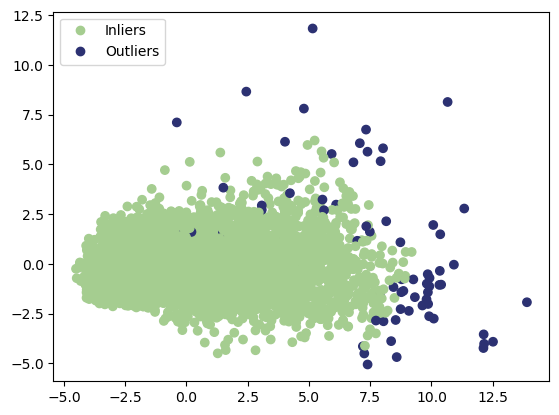

In [128]:
pca = PCA(n_components=2)
pca_data = pd.DataFrame(pca.fit_transform(X), columns=['PC1', 'PC2'])
pca_data['score']= df_original['score'].values
fig = plt.figure()
ax = fig.add_subplot()

scatter = ax.scatter(pca_data['PC1'],
                     pca_data['PC2'],
                     c=pca_data['score'],
                     cmap='crest')

handles, labels = scatter.legend_elements()
plt.legend(handles, ['Inliers', 'Outliers'], loc='upper left')

# FINAL DATASET

In [129]:
df_original.columns

Index(['id', 'Basic_Demos-Age', 'Basic_Demos-Sex', 'Physical-BMI',
       'Physical-Height', 'Physical-Weight', 'Physical-MAP_CAL',
       'FGC-FGC_CORE_CAL', 'FGC-FGC_GS_CAL', 'FGC-FGC_SR_CAL',
       'BIA-BIA_Activity_Level_num', 'BIA-BIA_BMC', 'BIA-BIA_DEE',
       'BIA-BIA_FFM', 'BIA-BIA_Fat', 'BIA-BIA_Frame_num', 'BIA-BIA_SMM',
       'BIA-BIA_TBW', 'sii', 'score'],
      dtype='object')

In [130]:
df_original.drop(columns=['score'], inplace=True)

In [131]:
df_original[(df_original['id'].isin(twice))]

,id,Basic_Demos-Age,Basic_Demos-Sex,Physical-BMI,Physical-Height,Physical-Weight,Physical-MAP_CAL,FGC-FGC_CORE_CAL,FGC-FGC_GS_CAL,FGC-FGC_SR_CAL,BIA-BIA_Activity_Level_num,BIA-BIA_BMC,BIA-BIA_DEE,BIA-BIA_FFM,BIA-BIA_Fat,BIA-BIA_Frame_num,BIA-BIA_SMM,BIA-BIA_TBW,sii
59,59,17,0,24.446886,68.000000,160.800000,95.000000,47.000000,115.100000,10.50000,4.0,3.502280,2298.130000,139.225600,21.574400,2.0,25.752900,42.541600,2.0
180,180,6,1,14.791120,50.000000,52.600000,62.333333,4.000000,18.613018,12.00000,2.0,22.435300,1530.520000,50.943230,1.656770,1.0,32.662300,27.440500,0.0
306,306,16,0,46.102914,67.500000,298.800000,100.333333,11.000000,34.600000,2.75000,1.0,7.434780,2887.120000,178.814000,119.986000,3.0,82.303300,132.055000,3.0
489,489,17,0,35.017194,69.500000,240.600000,122.000000,30.000000,53.100000,15.15000,5.0,11.632400,5061.840000,166.909800,73.690200,2.0,97.923100,123.830000,0.0
570,570,15,0,33.104936,69.000000,224.200000,119.000000,22.000000,37.350000,10.50000,2.0,7.882090,3358.140000,165.817200,58.382800,3.0,94.946500,123.560000,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7207,7207,20,0,37.511877,72.570000,281.013843,88.393939,12.500000,25.583333,8.17500,3.0,9.286550,2738.100000,179.993113,101.020730,3.0,67.563704,80.235114,2.0
7224,7224,9,1,18.000000,67.085714,115.233108,84.166427,12.787145,18.204545,8.49242,3.0,41.515953,1711.477348,99.668648,15.564460,1.0,29.923986,29.879288,0.0
7304,7304,9,0,16.101998,56.800000,73.896033,80.833333,12.787145,14.775000,3.00000,1.0,33.027024,1767.697081,64.697952,9.198081,2.0,25.830364,36.283486,0.0
7475,7475,17,0,36.509036,73.210000,278.346559,97.166667,26.500000,38.525000,8.00000,2.0,7.069773,3036.108086,246.623780,31.722779,3.0,65.311851,99.605311,1.0


In [132]:
df_original.drop(index=df_original[(df_original['id'].isin(twice))].index, inplace=True)


In [133]:
df_original.describe()

,id,Basic_Demos-Age,Basic_Demos-Sex,Physical-BMI,Physical-Height,Physical-Weight,Physical-MAP_CAL,FGC-FGC_CORE_CAL,FGC-FGC_GS_CAL,FGC-FGC_SR_CAL,BIA-BIA_Activity_Level_num,BIA-BIA_BMC,BIA-BIA_DEE,BIA-BIA_FFM,BIA-BIA_Fat,BIA-BIA_Frame_num,BIA-BIA_SMM,BIA-BIA_TBW,sii
count,8382.000000,8382.000000,8382.000000,8382.000000,8382.000000,8382.000000,8382.000000,8382.000000,8382.000000,8382.000000,8382.000000,8382.000000,8382.000000,8382.000000,8382.000000,8382.000000,8382.000000,8382.000000,8382.000000
mean,4235.565855,10.200668,0.403722,19.298505,56.359446,91.197142,84.576598,15.455501,20.128154,8.403747,2.769983,4.840127,1894.999004,70.349333,20.847809,1.711644,29.802970,44.404819,0.440706
std,2443.544757,3.545139,0.490672,4.309242,7.712793,40.070129,9.662046,11.339055,5.235972,2.019214,0.819210,2.187917,492.512822,30.369940,16.018380,0.562526,11.731804,13.623690,0.728511
min,0.000000,5.000000,0.000000,8.522436,33.000000,31.800000,37.666667,0.500000,0.100000,1.000000,1.000000,0.009889,1073.450000,1.181133,0.026117,1.000000,0.590566,20.589200,0.000000
25%,2119.250000,7.000000,0.000000,16.483402,50.750000,62.434053,79.666667,8.000000,18.025000,7.500000,2.000000,3.328853,1601.695000,50.347656,10.409017,1.000000,22.586778,36.406994,0.000000
50%,4238.500000,10.000000,0.000000,17.937682,55.020000,77.540980,83.333333,12.787145,18.613018,8.500000,3.000000,4.481604,1800.600699,61.805607,15.811750,2.000000,25.641761,42.380000,0.000000
75%,6351.750000,12.000000,1.000000,21.126871,62.000000,112.189403,88.166667,20.500000,20.626092,9.000000,3.000000,5.779590,2095.450000,83.342844,26.921012,2.000000,35.926887,47.096147,1.000000
max,8459.000000,22.000000,1.000000,59.132048,78.500000,289.628663,164.333333,150.000000,70.800000,21.000000,5.000000,31.971308,17311.200000,268.694823,153.820000,3.000000,89.488400,132.884000,3.000000


In [134]:
df_original.to_csv('../1.DATASET/CMI_FINAL_OD.csv', index=False)